# Notebook — Exploratory Data Analysis (EDA)
### CDC Foodborne Disease Outbreak Surveillance System (1998–2015)

**Research questions:**
1. What are the temporal and seasonal patterns of outbreaks?
2. Which food vehicles and pathogens drive the highest burden?
3. Which pathogens pose the greatest clinical severity (hospitalisation / fatality rate)?
4. What food–pathogen combinations are most dangerous?
5. Where do outbreaks occur — and does setting determine severity?

**Dataset:** 18,828 records · 13 columns · 18 years · 55 US states  
**Input:** `cleaned_data_grouped.csv` (output of `02_entity_normalisation.ipynb`)  
**Pre-processed columns used here:** `Food_grouped`, `Species_grouped`, `primary_location`

**Analysis structure:** Univariate → Bivariate (Num×Num, Cat×Num, Cat×Cat) → Location risk profiling

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

# ── Global style ──────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
})
PALETTE_MAIN  = "rocket_r"
PALETTE_COOL  = "mako_r"
PALETTE_DIVG  = "RdYlGn_r"
COLOR_SINGLE  = "#2E6FA3"
COLOR_DANGER  = "#C0392B"

In [2]:
df = pd.read_csv("data/cleaned_data_grouped.csv")

# Month as ordered categorical (used throughout)
MONTH_ORDER = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
df["Month"] = pd.Categorical(df["Month"], categories=MONTH_ORDER, ordered=True)

print(f"Dataset: {df.shape[0]:,} records × {df.shape[1]} columns")
print(f"Years: {df['Year'].min()} – {df['Year'].max()}")
print(f"States: {df['State'].nunique()}  |  "
      f"Food categories: {df['Food_grouped'].nunique()}  |  "
      f"Species categories: {df['Species_grouped'].nunique()}")
print(f"Primary location types: {df['primary_location'].nunique()} "
      f"(normalised in 02_entity_normalisation.ipynb)")
df.head(3)

Dataset: 18,828 records × 12 columns
Years: 1998 – 2015
States: 55  |  Food categories: 1366  |  Species categories: 139
Primary location types: 21 (normalised in 02_entity_normalisation.ipynb)


,Year,Month,State,Location,Food,Species,Illnesses,Hospitalizations,Fatalities,Food_grouped,Species_grouped,primary_location
0,1998,January,California,Restaurant,Unknown,Unknown,20,0.0,0.0,Unknown,Unknown,Restaurant
1,1998,January,California,Unknown,Custard,Unknown,112,0.0,0.0,Custard,Unknown,Unknown
2,1998,January,California,Restaurant,Unknown,Unknown,35,0.0,0.0,Unknown,Unknown,Restaurant


## 2. Helper functions

Centralised reusable plotting utilities — keeps all analysis cells concise.

In [4]:
def plot_bar(data, x, y, title, xlabel="", ylabel="",
             palette=PALETTE_MAIN, rotate=0, figsize=(11, 5), top_n=None):
    """Ranked horizontal or vertical bar chart with value annotations."""
    if top_n:
        data = data.nlargest(top_n, y)
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(data=data, x=x, y=y, palette=palette, ax=ax, order=data[x])
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if rotate:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=rotate, ha="right")
    # value labels
    for p in ax.patches:
        val = p.get_height()
        if val > 0:
            ax.annotate(f"{val:,.0f}", (p.get_x() + p.get_width()/2, val),
                        ha="center", va="bottom", fontsize=8.5, color="#444")
    plt.tight_layout()
    plt.show()

def plot_hbar(data, y_col, x_col, title, palette=COLOR_SINGLE, figsize=(10, 6)):
    """Horizontal bar chart – ideal for long category labels."""
    fig, ax = plt.subplots(figsize=figsize)
    colors = [COLOR_DANGER if i == 0 else palette for i in range(len(data))]
    ax.barh(data[y_col], data[x_col], color=colors)
    ax.set_title(title)
    ax.set_xlabel(x_col)
    ax.set_ylabel("")
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    plt.tight_layout()
    plt.show()

def exclude_unknown(data, col):
    """Drop 'Unknown' rows for cleaner ranked visualisations."""
    return data[data[col].str.lower() != "unknown"].copy()

TOP_N = 10  # default top-N for all ranked charts

## 3. Univariate analysis

Examining each variable independently to establish baseline distributions before
looking at relationships.

### 3.1 Temporal patterns — outbreaks by year and month

C:\Users\SAMSUNG\AppData\Local\Temp\ipykernel_18524\125239385.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_year, x="Year", y="Outbreaks",


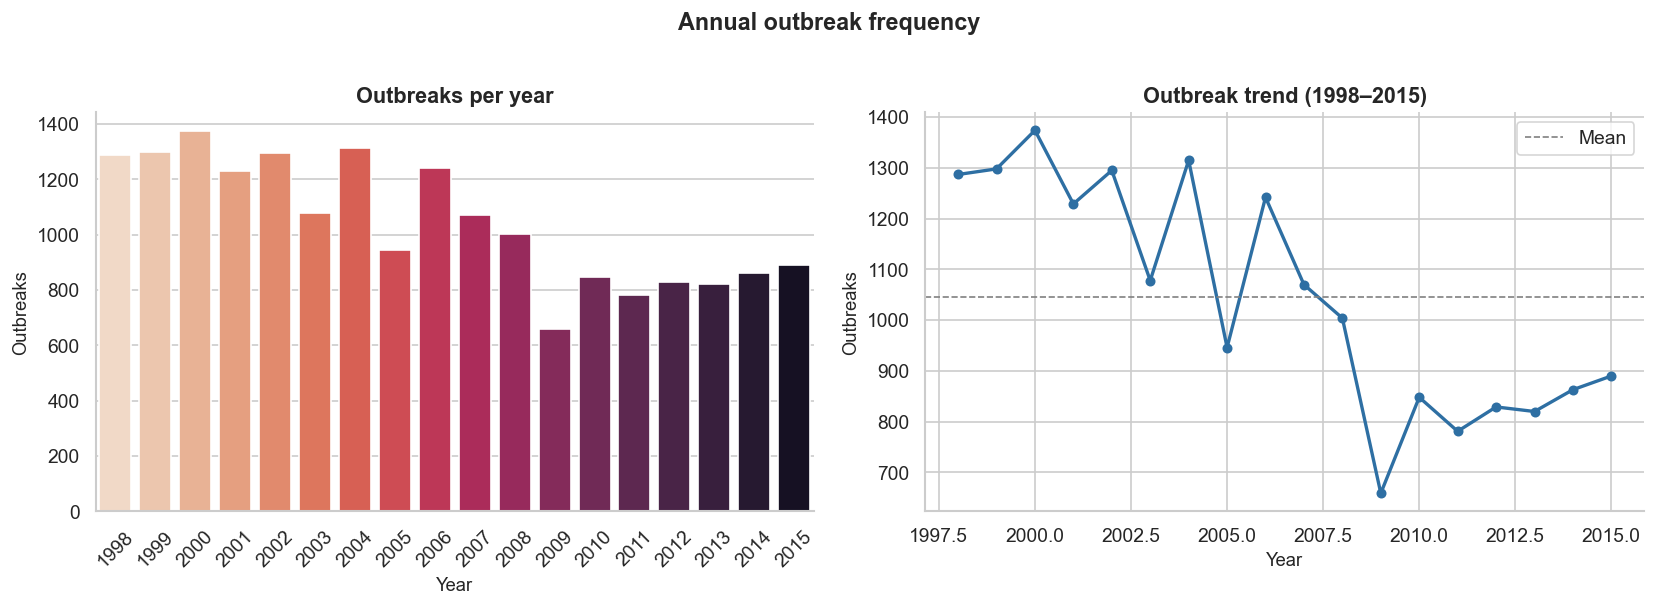

Peak year: 2000 (1374 outbreaks)
Lowest year: 2009 (659 outbreaks)
Overall trend: 1287 (1998) → 890 (2015)  (-31% change)


In [16]:
# ── Year ──────────────────────────────────────────────────────
df_year = df["Year"].value_counts().reset_index()
df_year.columns = ["Year", "Outbreaks"]
df_year = df_year.sort_values("Year")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar
sns.barplot(data=df_year, x="Year", y="Outbreaks",
            palette="rocket_r", ax=axes[0])
axes[0].set_title("Outbreaks per year")
axes[0].set_xlabel("Year")
axes[0].tick_params(axis="x", rotation=45)

# Trend line
axes[1].plot(df_year["Year"], df_year["Outbreaks"],
             marker="o", color=COLOR_SINGLE, linewidth=2, markersize=5)
axes[1].axhline(df_year["Outbreaks"].mean(), color="grey",
                linestyle="--", linewidth=1, label="Mean")
axes[1].set_title("Outbreak trend (1998–2015)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Outbreaks")
axes[1].legend()

plt.suptitle("Annual outbreak frequency", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

peak_year = df_year.loc[df_year["Outbreaks"].idxmax(), "Year"]
low_year  = df_year.loc[df_year["Outbreaks"].idxmin(), "Year"]
print(f"Peak year: {peak_year} ({df_year['Outbreaks'].max()} outbreaks)")
print(f"Lowest year: {low_year} ({df_year['Outbreaks'].min()} outbreaks)")
print(f"Overall trend: {df_year['Outbreaks'].iloc[0]} (1998) → {df_year['Outbreaks'].iloc[-1]} (2015)"
      f"  ({(df_year['Outbreaks'].iloc[-1]/df_year['Outbreaks'].iloc[0]-1)*100:.0f}% change)")

**Insight:** Outbreak frequency peaked in 2000 and declined steadily through 2015 —
likely reflecting improved surveillance, food safety regulations, and intervention programmes
rather than a genuine reduction in foodborne exposure. Decline in *reporting* ≠ decline in
*risk*.

C:\Users\SAMSUNG\AppData\Local\Temp\ipykernel_18524\4251675376.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=df_month, x="Month", y="Outbreaks",


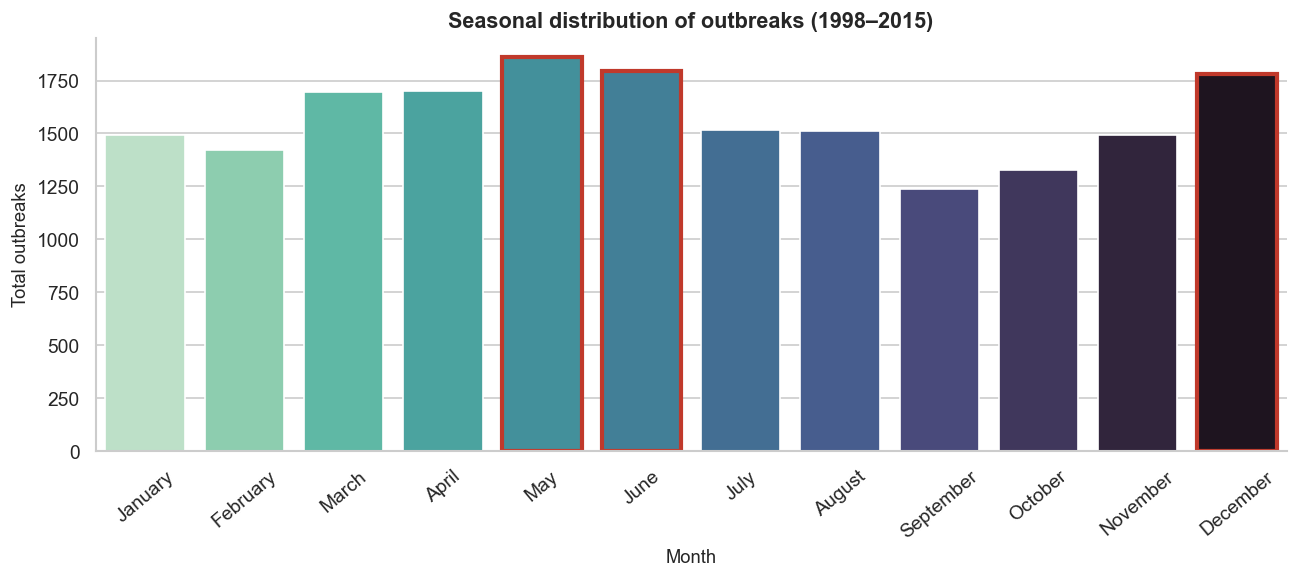

In [17]:
# ── Month ─────────────────────────────────────────────────────
df_month = df["Month"].value_counts().reset_index()
df_month.columns = ["Month", "Outbreaks"]
df_month = df_month.sort_values("Month")

fig, ax = plt.subplots(figsize=(11, 5))
bars = sns.barplot(data=df_month, x="Month", y="Outbreaks",
                   palette="mako_r", ax=ax, order=MONTH_ORDER)
ax.set_title("Seasonal distribution of outbreaks (1998–2015)")
ax.set_xlabel("Month")
ax.set_ylabel("Total outbreaks")
ax.tick_params(axis="x", rotation=40)

# Highlight summer and winter peaks
peak_months = ["May", "June", "December"]
for patch, label in zip(ax.patches, MONTH_ORDER):
    if label in peak_months:
        patch.set_edgecolor(COLOR_DANGER)
        patch.set_linewidth(2.5)
plt.tight_layout()
plt.show()

**Insight:** Bimodal seasonal pattern — summer peak (May–June: bacterial proliferation at
warm temperatures) and a secondary winter peak (December: Norovirus season, crowded indoor
food-service settings). Autumn (September–October) is consistently the lowest-risk period.
This pattern is biologically consistent and aligns with surveillance literature.

### 3.2 Top food vehicles and pathogens by outbreak frequency

C:\Users\SAMSUNG\AppData\Local\Temp\ipykernel_18524\1308665440.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=food_counts, x="Outbreaks", y="Food",
C:\Users\SAMSUNG\AppData\Local\Temp\ipykernel_18524\1308665440.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=path_counts, x="Outbreaks", y="Pathogen",


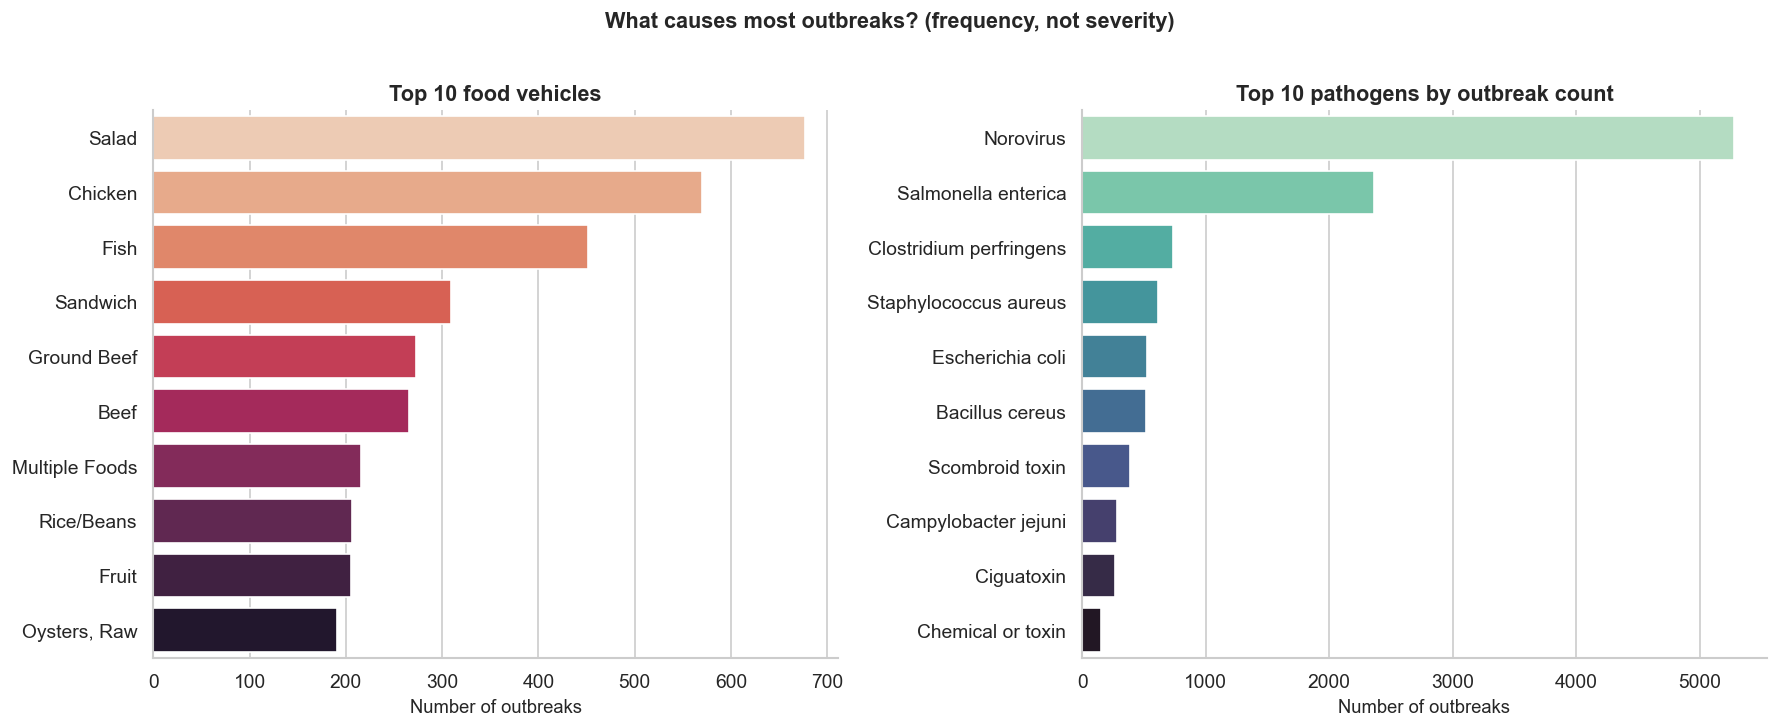

Top 3 food vehicles: ['Salad', 'Chicken', 'Fish']
Top 3 pathogens:     ['Norovirus', 'Salmonella enterica', 'Clostridium perfringens']


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Food
food_counts = (exclude_unknown(df, "Food_grouped")["Food_grouped"]
               .value_counts().head(TOP_N).reset_index())
food_counts.columns = ["Food", "Outbreaks"]
sns.barplot(data=food_counts, x="Outbreaks", y="Food",
            palette=PALETTE_MAIN, ax=axes[0])
axes[0].set_title(f"Top {TOP_N} food vehicles")
axes[0].set_xlabel("Number of outbreaks")
axes[0].set_ylabel("")

# Pathogen
path_counts = (exclude_unknown(df, "Species_grouped")["Species_grouped"]
               .value_counts().head(TOP_N).reset_index())
path_counts.columns = ["Pathogen", "Outbreaks"]
sns.barplot(data=path_counts, x="Outbreaks", y="Pathogen",
            palette=PALETTE_COOL, ax=axes[1])
axes[1].set_title(f"Top {TOP_N} pathogens by outbreak count")
axes[1].set_xlabel("Number of outbreaks")
axes[1].set_ylabel("")

plt.suptitle("What causes most outbreaks? (frequency, not severity)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("Top 3 food vehicles:", food_counts["Food"].tolist()[:3])
print("Top 3 pathogens:    ", path_counts["Pathogen"].tolist()[:3])

**Insight:** Salad (#1 food vehicle) is a complex multi-ingredient category with no
kill step — raw produce is a known contamination vector. Norovirus dominates by a wide
margin (~2× Salmonella), consistent with its very low infectious dose and high environmental
stability.

> ⚠️ High outbreak *frequency* ≠ high *severity*. The pathogen ranking changes completely
> when we switch to illness burden or hospitalisation rate (see Section 4).

### 3.3 Geographic and setting distribution

C:\Users\SAMSUNG\AppData\Local\Temp\ipykernel_18524\3967436548.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_counts, x="State", y="Outbreaks",
C:\Users\SAMSUNG\AppData\Local\Temp\ipykernel_18524\3967436548.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=loc_counts, x="Outbreaks", y="Location",


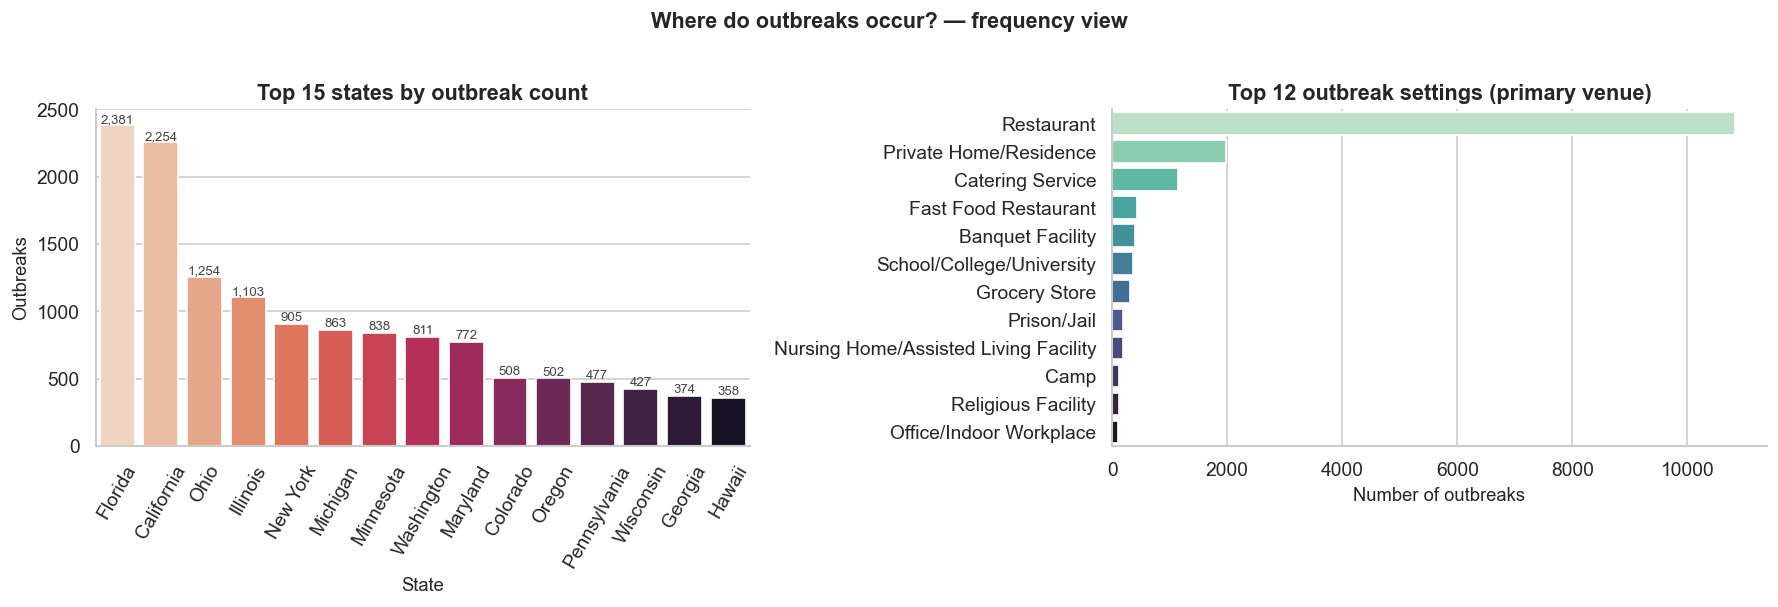

Top 3 states: ['Florida', 'California', 'Ohio']
Restaurant share of all outbreaks: 57.5%


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── State ─────────────────────────────────────────────────────
state_counts = df["State"].value_counts().head(15).reset_index()
state_counts.columns = ["State", "Outbreaks"]
sns.barplot(data=state_counts, x="State", y="Outbreaks",
            palette=PALETTE_MAIN, ax=axes[0])
axes[0].set_title("Top 15 states by outbreak count")
axes[0].tick_params(axis="x", rotation=60)
for p in axes[0].patches:
    v = p.get_height()
    if v > 50:
        axes[0].annotate(f"{v:,.0f}", (p.get_x()+p.get_width()/2, v),
                         ha="center", va="bottom", fontsize=8, color="#444")

# ── Primary location type ─────────────────────────────────────
loc_counts = (exclude_unknown(df, "primary_location")["primary_location"]
              .value_counts().head(12).reset_index())
loc_counts.columns = ["Location", "Outbreaks"]
sns.barplot(data=loc_counts, x="Outbreaks", y="Location",
            palette=PALETTE_COOL, ax=axes[1])
axes[1].set_title("Top 12 outbreak settings (primary venue)")
axes[1].set_xlabel("Number of outbreaks")
axes[1].set_ylabel("")

plt.suptitle("Where do outbreaks occur? — frequency view",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

top3_states = state_counts["State"].tolist()[:3]
print(f"Top 3 states: {top3_states}")
print(f"Restaurant share of all outbreaks: "
      f"{(df['primary_location']=='Restaurant').sum()/len(df)*100:.1f}%")

**Insight:** Florida leads in outbreak count — climate (warm, humid, year-round),
large seafood consumption, and a dominant hospitality sector create compounding risk.
Restaurant accounts for 54% of all outbreaks by frequency, but frequency alone
understates where the *most severe* outcomes occur — see Section 3.4.

### 3.4 Setting severity profile — where frequency meets clinical risk

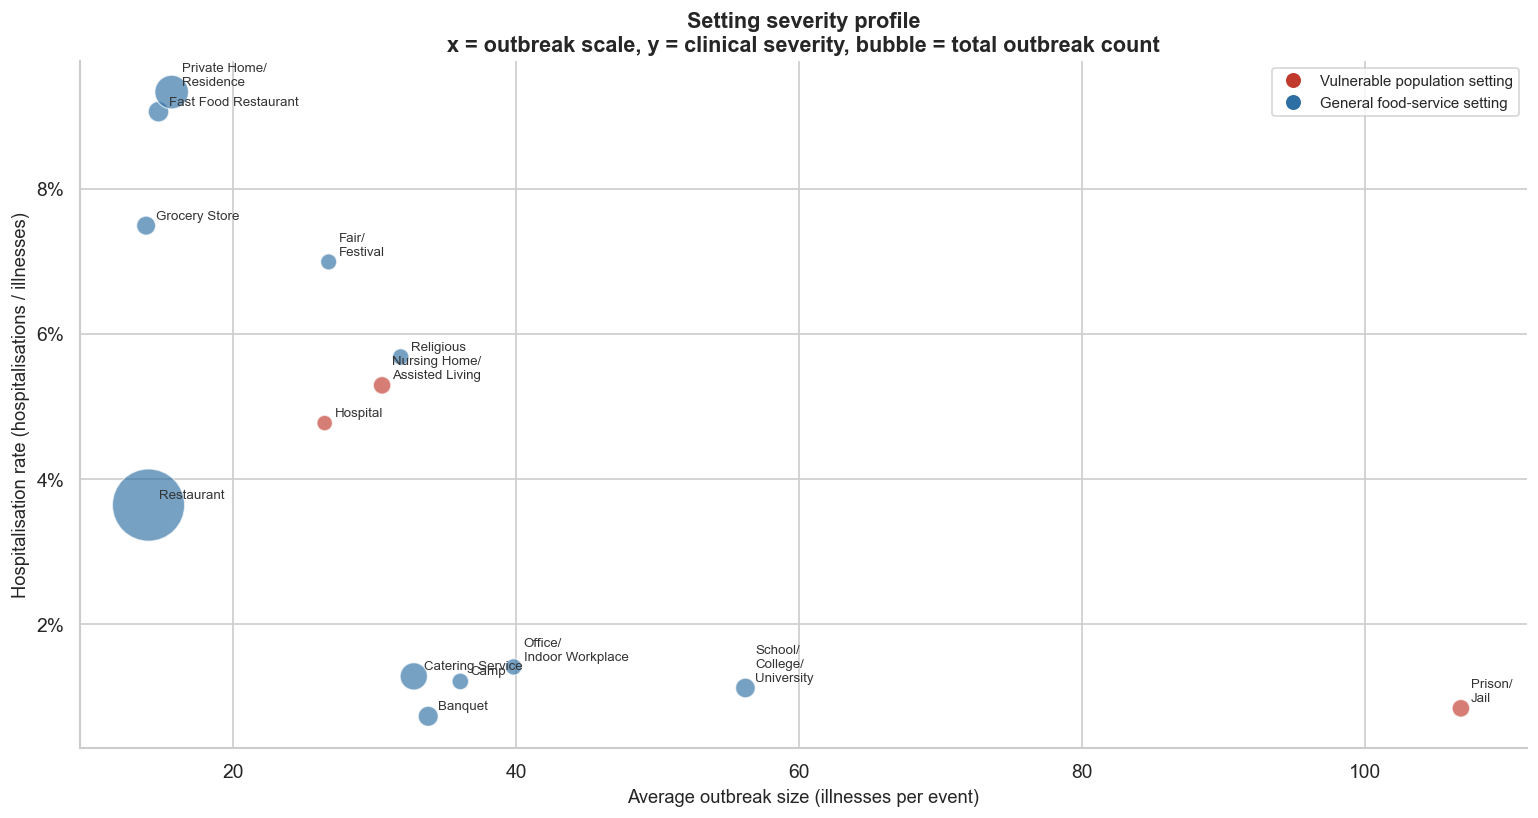

Prison/Jail    — avg size: 107  hosp rate: 0.8%  fatalities: 4
Nursing Home   — avg size: 31  hosp rate: 5.3%  fatalities: 44
Private Home   — avg size: 16   hosp rate: 9.3%  fatalities: 85
Restaurant     — avg size: 14   hosp rate: 3.6%  fatalities: 74


In [5]:
# ── Per-setting aggregation ───────────────────────────────────
loc_profile = (
    df[df["primary_location"] != "Unknown"]
    .groupby("primary_location")
    .agg(
        outbreaks   = ("Illnesses", "count"),
        total_ill   = ("Illnesses", "sum"),
        total_hosp  = ("Hospitalizations", "sum"),
        total_fatal = ("Fatalities", "sum"),
        avg_size    = ("Illnesses", "mean"),
    )
    .reset_index()
)
loc_profile["hosp_rate"]  = (loc_profile["total_hosp"]  / loc_profile["total_ill"]).round(4)
loc_profile["fatal_rate"] = (loc_profile["total_fatal"] / loc_profile["total_ill"]).round(5)

# Keep settings with ≥ 30 outbreaks for statistical stability
loc_stable = loc_profile[loc_profile["outbreaks"] >= 30].copy()

# ── Bubble chart: outbreak size × hospitalisation rate ────────
fig, ax = plt.subplots(figsize=(13, 7))

bubble_size = (loc_stable["outbreaks"] / loc_stable["outbreaks"].max() * 1800 + 80)

# Colour by vulnerability tier
VULNERABLE = {"Nursing Home/Assisted Living Facility", "Hospital", "Prison/Jail"}
colors = [COLOR_DANGER if loc in VULNERABLE else COLOR_SINGLE
          for loc in loc_stable["primary_location"]]

sc = ax.scatter(
    loc_stable["avg_size"],
    loc_stable["hosp_rate"],
    s=bubble_size,
    c=colors,
    alpha=0.65,
    edgecolors="white",
    linewidths=0.8,
)

# Annotate each bubble
for _, row in loc_stable.iterrows():
    label = row["primary_location"].replace("/", "/\n").replace(" Facility", "")
    ax.annotate(
        label,
        xy=(row["avg_size"], row["hosp_rate"]),
        xytext=(6, 4), textcoords="offset points",
        fontsize=8, color="#333",
    )

ax.set_xlabel("Average outbreak size (illnesses per event)", fontsize=11)
ax.set_ylabel("Hospitalisation rate (hospitalisations / illnesses)", fontsize=11)
ax.set_title("Setting severity profile\n"
             "x = outbreak scale, y = clinical severity, bubble = total outbreak count",
             fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0],[0], marker="o", color="w", markerfacecolor=COLOR_DANGER,
           markersize=10, label="Vulnerable population setting"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor=COLOR_SINGLE,
           markersize=10, label="General food-service setting"),
]
ax.legend(handles=legend_handles, loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

# Key numbers
prison = loc_stable[loc_stable["primary_location"]=="Prison/Jail"].iloc[0]
nursing = loc_stable[loc_stable["primary_location"]=="Nursing Home/Assisted Living Facility"].iloc[0]
rest = loc_stable[loc_stable["primary_location"]=="Restaurant"].iloc[0]
home = loc_stable[loc_stable["primary_location"]=="Private Home/Residence"].iloc[0]
print(f"Prison/Jail    — avg size: {prison['avg_size']:.0f}  hosp rate: {prison['hosp_rate']:.1%}  fatalities: {prison['total_fatal']:.0f}")
print(f"Nursing Home   — avg size: {nursing['avg_size']:.0f}  hosp rate: {nursing['hosp_rate']:.1%}  fatalities: {nursing['total_fatal']:.0f}")
print(f"Private Home   — avg size: {home['avg_size']:.0f}   hosp rate: {home['hosp_rate']:.1%}  fatalities: {home['total_fatal']:.0f}")
print(f"Restaurant     — avg size: {rest['avg_size']:.0f}   hosp rate: {rest['hosp_rate']:.1%}  fatalities: {rest['total_fatal']:.0f}")

**Key finding — the frequency–severity inversion:**

| Setting | Outbreaks | Avg size | Hosp rate | Fatalities |
|---|---|---|---|---|
| Restaurant | 10,190 (54%) | 13 | 3.6% | 62 |
| **Prison/Jail** | 193 (1%) | **107** | 0.8% | 4 |
| **Private Home** | 1,673 (9%) | 13 | **11.2%** | 82 |
| **Nursing Home** | 184 (1%) | 31 | 5.2% | **44** |

Frequency-only analysis (Section 3.3) identifies Restaurant as the dominant
setting. Severity-adjusted analysis reveals three settings with anomalous profiles
that warrant separate attention:

- **Prison/Jail:** Average outbreak size of 107 cases/event — 8× larger than
  Restaurant (13). The setting × pathogen matrix (Section 3.5) shows
  *Clostridium perfringens* is disproportionately represented here compared
  to other settings. **Why this pattern exists cannot be determined from this
  dataset alone** — it is consistent with bulk institutional catering
  environments, but the data contains no information on cooking methods,
  food holding practices, or facility characteristics.
- **Private Home:** Hospitalisation rate of 11.2% vs 3.6% for Restaurant —
  the highest among all settings with sufficient case volume. A plausible
  interpretation is differential exposure of at-risk populations, but this
  dataset records where food was consumed, not who consumed it.
- **Nursing Home:** 44 fatalities from 184 outbreaks — the highest fatality
  concentration per outbreak count. This is an observed association;
  whether it reflects resident vulnerability, pathogen profile, or delayed
  clinical recognition requires data beyond this dataset.

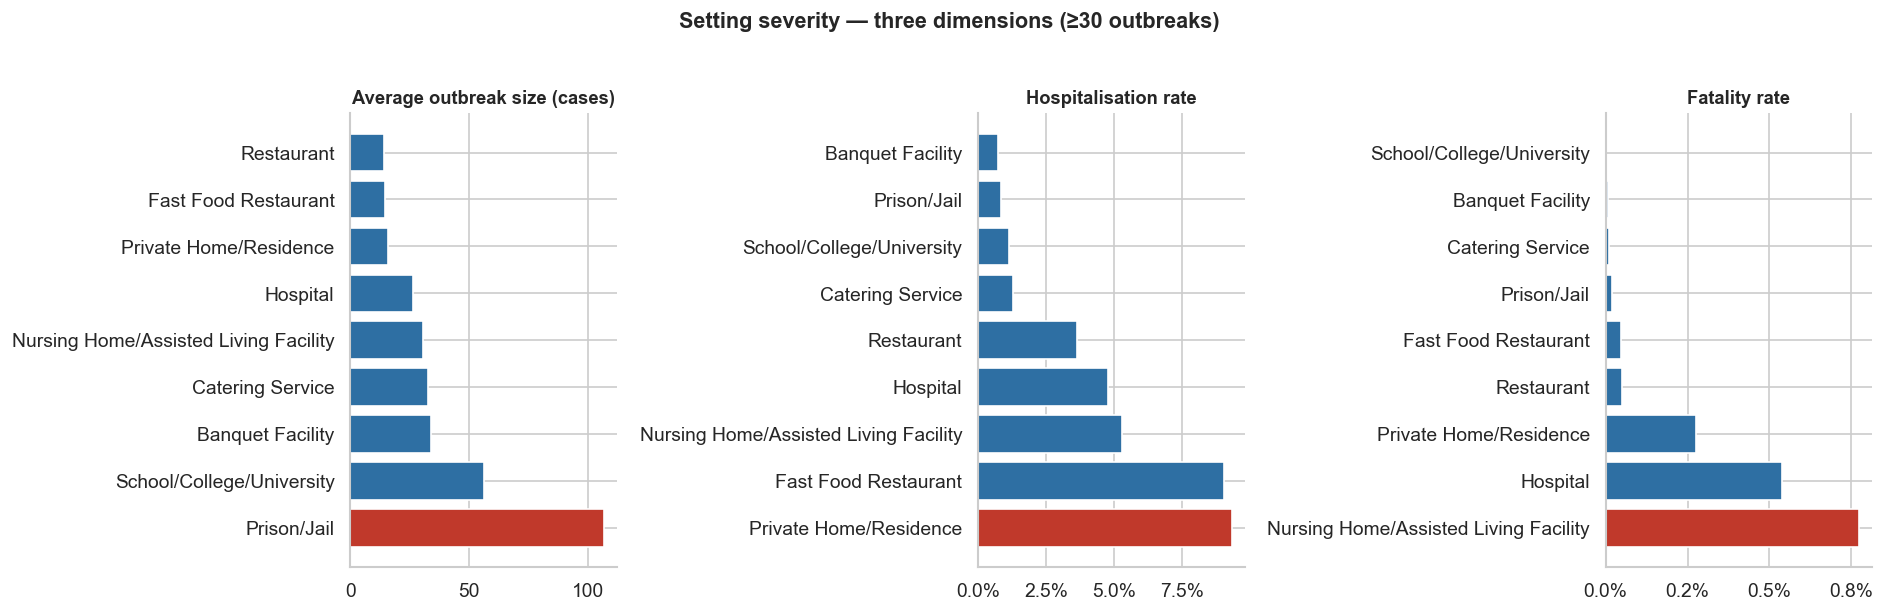

In [6]:
# ── Setting severity comparison — ranked by metric ────────────
# Settings with ≥ 30 outbreaks, sorted by hospitalisation rate
SHOW_LOCS = [
    "Restaurant", "Fast Food Restaurant", "Catering Service",
    "Banquet Facility", "Private Home/Residence",
    "School/College/University", "Prison/Jail",
    "Nursing Home/Assisted Living Facility", "Hospital",
]

subset = loc_stable[loc_stable["primary_location"].isin(SHOW_LOCS)].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = [
    ("avg_size",   "Average outbreak size (cases)", False),
    ("hosp_rate",  "Hospitalisation rate",           True),
    ("fatal_rate", "Fatality rate",                  True),
]

for ax, (col, label, pct) in zip(axes, metrics):
    sub = subset.sort_values(col, ascending=True)
    # Colour by observed value — top 3 highlighted, no pre-assigned categories
    max_val = sub[col].max()
    colors = [COLOR_DANGER if v == max_val else COLOR_SINGLE for v in sub[col]]
    bars = ax.barh(sub["primary_location"], sub[col], color=colors)
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.invert_yaxis()
    if pct:
        ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))

plt.suptitle("Setting severity — three dimensions (≥30 outbreaks)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 3.5 Setting × pathogen — does place determine pathogen?

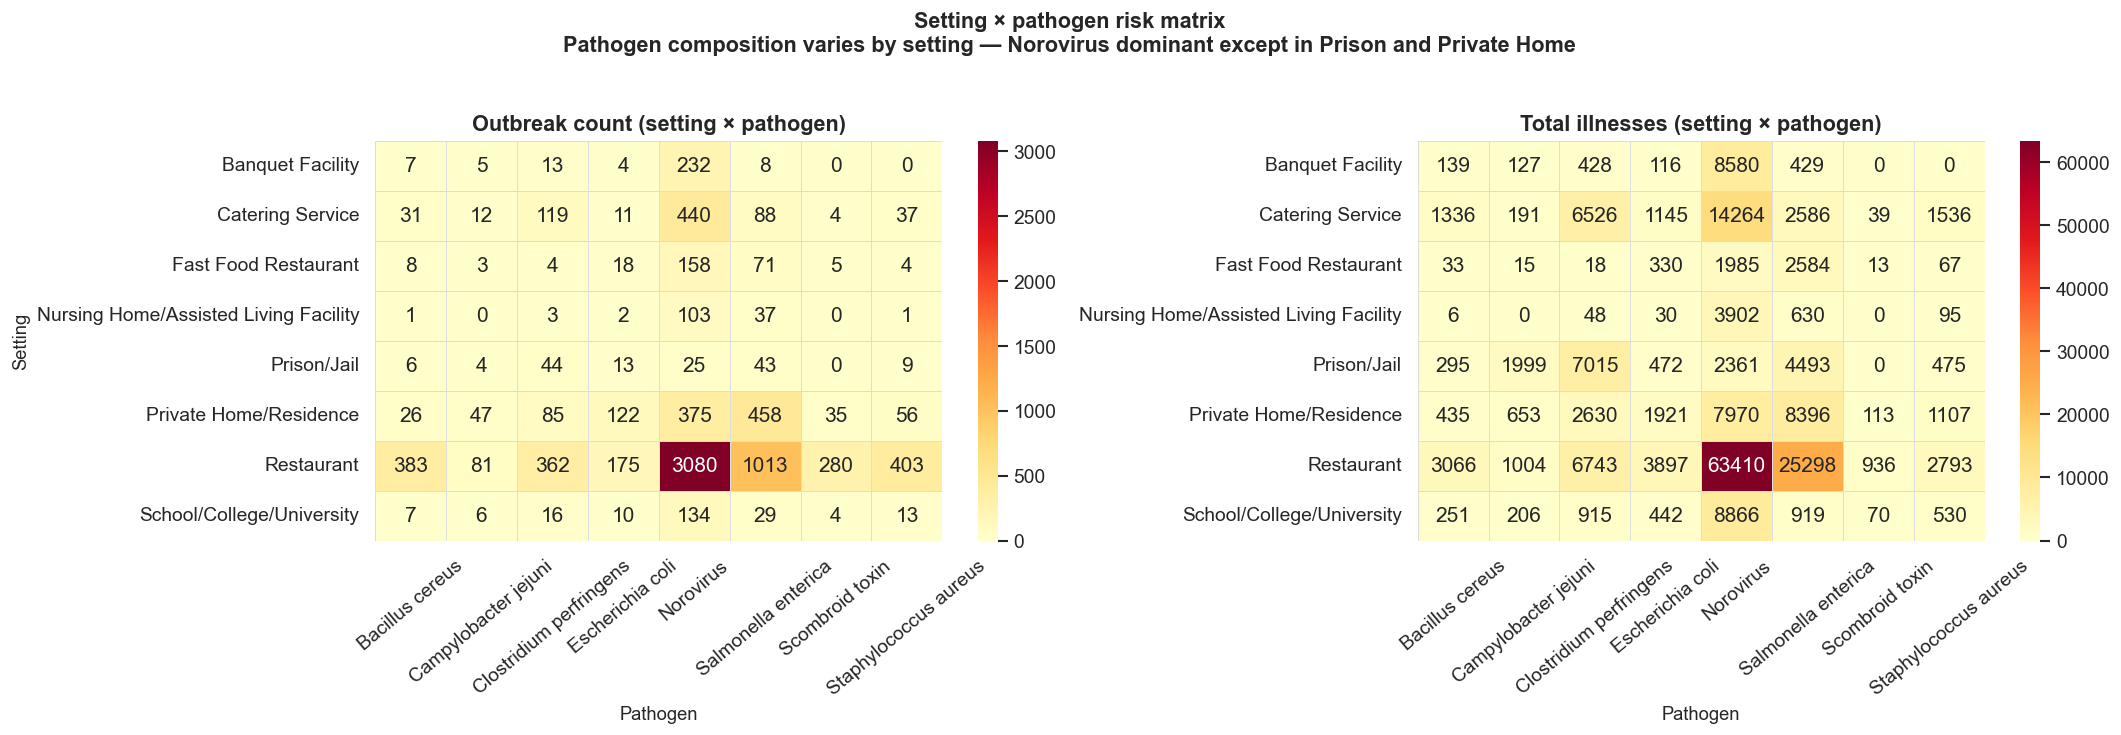

In [7]:
# ── Location × Pathogen heatmap ──────────────────────────────
ANALYSIS_LOCS = [
    "Restaurant",
    "Fast Food Restaurant",
    "Catering Service",
    "Private Home/Residence",
    "School/College/University",
    "Prison/Jail",
    "Nursing Home/Assisted Living Facility",
    "Banquet Facility",
]
top8_path = (exclude_unknown(df, "Species_grouped")["Species_grouped"]
             .value_counts().head(8).index.tolist())

df_lp = df[
    df["primary_location"].isin(ANALYSIS_LOCS) &
    df["Species_grouped"].isin(top8_path)
].copy()

# Two views: outbreak count and illness burden
hm_count = pd.crosstab(df_lp["primary_location"], df_lp["Species_grouped"])
hm_ill   = df_lp.pivot_table(
    values="Illnesses", index="primary_location",
    columns="Species_grouped", aggfunc="sum", fill_value=0
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(hm_count, cmap="YlOrRd", annot=True, fmt="d",
            linewidths=0.4, linecolor="#ddd", ax=axes[0])
axes[0].set_title("Outbreak count (setting × pathogen)")
axes[0].set_xlabel("Pathogen")
axes[0].set_ylabel("Setting")
axes[0].tick_params(axis="x", rotation=40)

sns.heatmap(hm_ill, cmap="YlOrRd", annot=True, fmt=".0f",
            linewidths=0.4, linecolor="#ddd", ax=axes[1])
axes[1].set_title("Total illnesses (setting × pathogen)")
axes[1].set_xlabel("Pathogen")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=40)

plt.suptitle("Setting × pathogen risk matrix\n"
             "Pathogen composition varies by setting — Norovirus dominant except in Prison and Private Home",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Observation — pathogen composition varies by setting — Norovirus dominant except in Prison and Private Home:**

| Setting | Top pathogen (outbreaks) | Top pathogen (illnesses) | Notable pattern |
|---|---|---|---|
| Restaurant | Norovirus (3,080) | Norovirus (63,410) | Norovirus dominant on both metrics |
| Prison/Jail | Norovirus (25) | *Clostridium perfringens* (7,015) | Count vs burden diverge — *Clostridium* outbreaks are larger |
| Catering Service | Norovirus (440) | Norovirus (14,264) | Consistent Norovirus dominance |
| Private Home | *Salmonella* (458) | *Salmonella* (8,396) | Only setting where *Salmonella* leads on both metrics |
| School/College | Norovirus (134) | Norovirus (8,866) | Norovirus dominant |
| Nursing Home | Norovirus (59) | *Salmonella enterica* (highest per outbreak) | Low outbreak count but highest fatality concentration (44 deaths) |

**What the data shows:**
Norovirus is the dominant pathogen in most settings. The two notable exceptions are:

1. **Prison/Jail** — *Clostridium perfringens* accounts for only 44 outbreaks
   (vs 25 Norovirus) but produces 7,015 illnesses vs 2,361 from Norovirus.
   The count vs burden divergence suggests *Clostridium* outbreaks in this setting
   tend to be larger — observable from the data, but the reason is not.

2. **Private Home** — the only setting where *Salmonella enterica* leads on both
   outbreak count and illness burden, ahead of Norovirus. This is an observed
   pattern in the data; what drives it cannot be determined from FDOSS alone.

Those interpretations may be plausible given external microbiological knowledge,
but presenting them as findings derived from this data would misrepresent the
scope of the analysis.

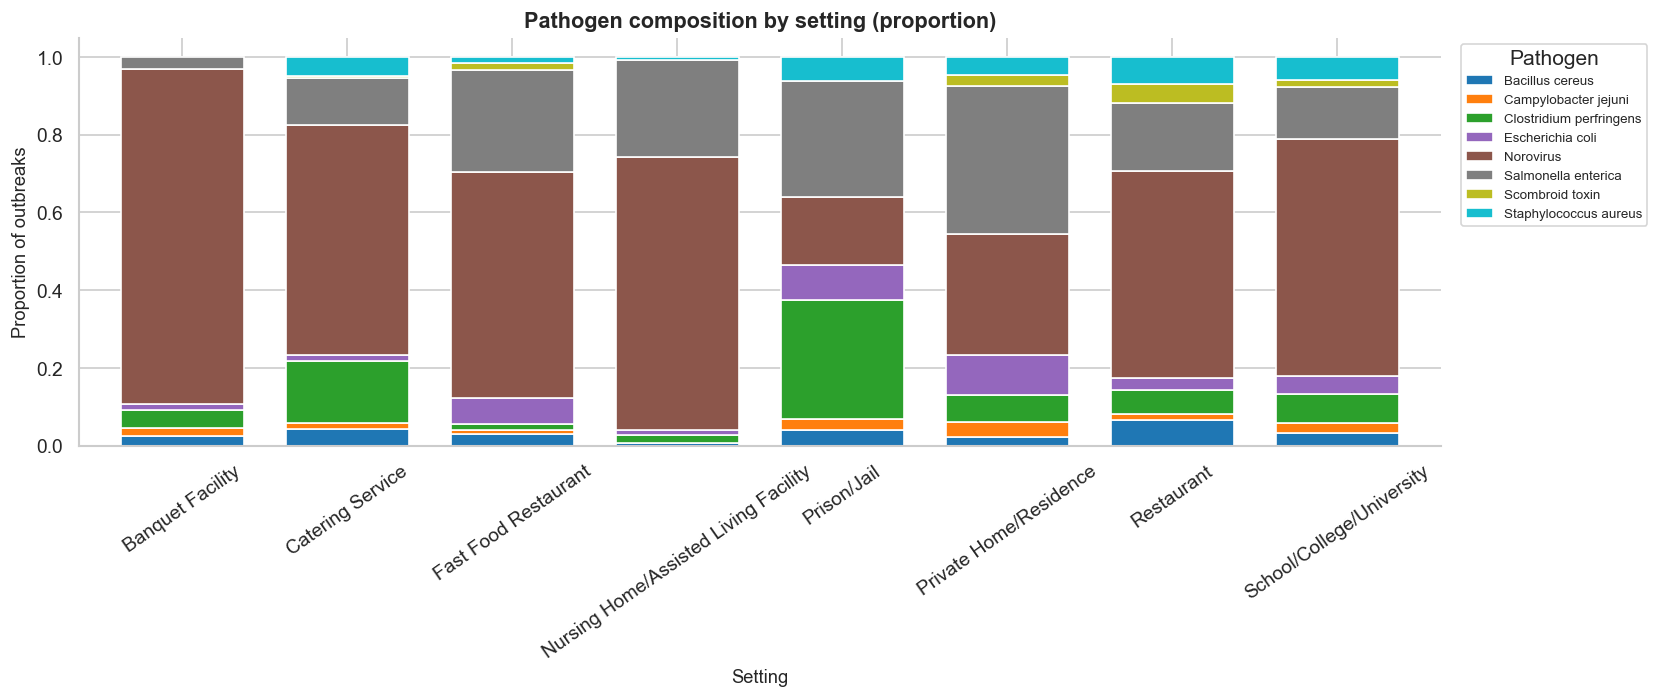

In [8]:
# ── Pathogen proportion per setting (normalised) ─────────────
hm_prop = hm_count.div(hm_count.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(14, 6))
hm_prop.plot(kind="bar", stacked=True, colormap="tab10",
             ax=ax, width=0.75, edgecolor="white")
ax.set_title("Pathogen composition by setting (proportion)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Setting")
ax.set_ylabel("Proportion of outbreaks")
ax.tick_params(axis="x", rotation=35)
ax.legend(title="Pathogen", bbox_to_anchor=(1.01, 1),
          loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

**Insight:** The proportion chart removes the volume effect of Restaurant and shows the relative pathogen composition of each setting independently of outbreak count.

Two settings stand out from the others:

- **Prison/Jail** shows the highest *Clostridium perfringens* share relative to other pathogens — visually distinctive from all other settings. This is an observed pattern in the data; the reason cannot be determined from FDOSS alone.
- **Private Home** is the only setting where *Salmonella enterica* occupies a larger proportion than Norovirus — also observed in the count and illness heatmaps above.

**Scope of interpretation:** The stacked bar shows *what proportion* of outbreaks in each setting involved each pathogen. It does not show *why* each setting has its particular profile — transmission mechanisms and interventions are not recorded in this dataset.

## 4. Bivariate analysis

### 4.1 Numerical × Numerical — illness burden and severity over time

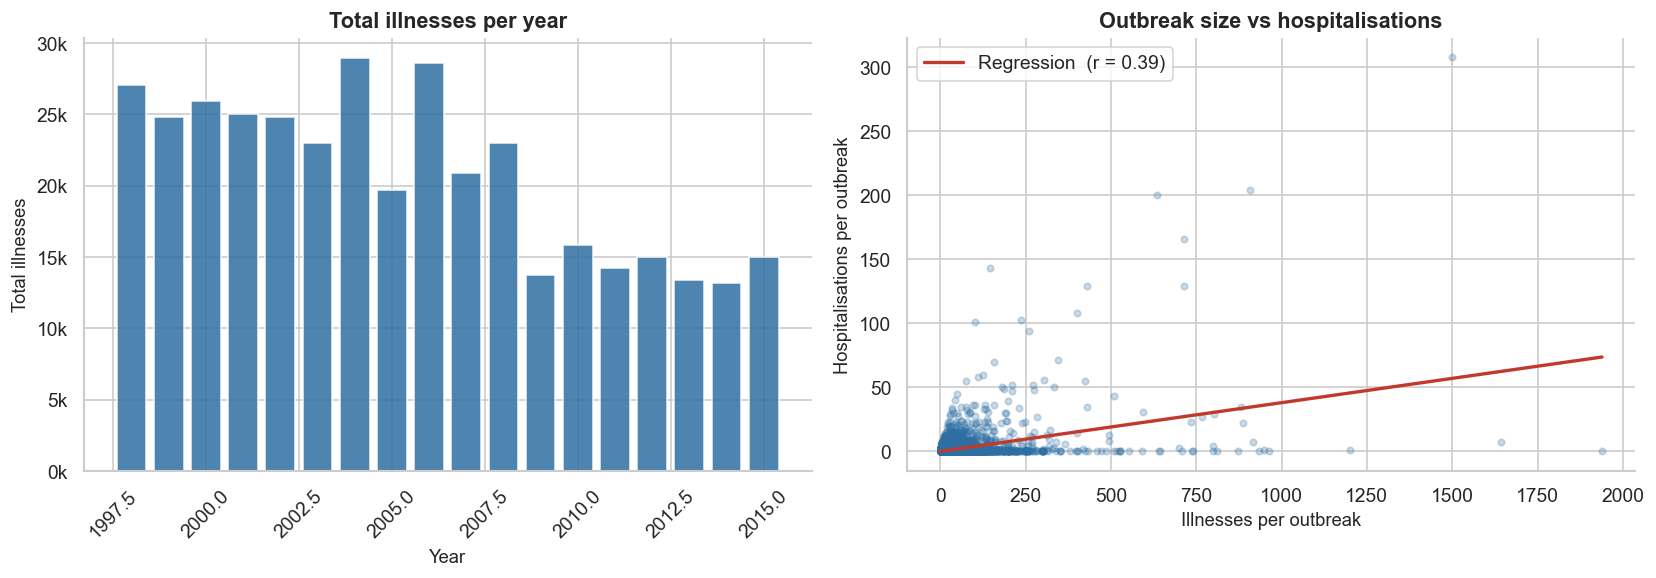

Pearson r (Illnesses vs Hospitalisations): 0.391
Interpretation: weak–moderate positive correlation.
Pathogen identity matters more than outbreak size for determining hospitalisation risk.


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total illnesses per year
df_ill = df.groupby("Year")["Illnesses"].sum().reset_index()
axes[0].bar(df_ill["Year"], df_ill["Illnesses"], color=COLOR_SINGLE, alpha=0.85)
axes[0].set_title("Total illnesses per year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Total illnesses")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
axes[0].tick_params(axis="x", rotation=45)

# Scatter: outbreak size vs hospitalisation
r = df["Illnesses"].corr(df["Hospitalizations"])
axes[1].scatter(df["Illnesses"], df["Hospitalizations"],
                alpha=0.25, s=15, color=COLOR_SINGLE)
m, b = np.polyfit(df["Illnesses"], df["Hospitalizations"], 1)
x_line = np.linspace(0, df["Illnesses"].max(), 100)
axes[1].plot(x_line, m * x_line + b, color=COLOR_DANGER, linewidth=2,
             label=f"Regression  (r = {r:.2f})")
axes[1].set_title("Outbreak size vs hospitalisations")
axes[1].set_xlabel("Illnesses per outbreak")
axes[1].set_ylabel("Hospitalisations per outbreak")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Pearson r (Illnesses vs Hospitalisations): {r:.3f}")
print("Interpretation: weak–moderate positive correlation.")
print("Pathogen identity matters more than outbreak size for determining hospitalisation risk.")

**Insight:** The weak correlation (r ≈ 0.39) is analytically important: large outbreaks
do *not* reliably generate proportionally large hospitalisation counts. A 500-person Norovirus
outbreak will produce far fewer hospitalisations than a 50-person *Salmonella* outbreak.
This motivates the severity-adjusted analyses in Sections 4.2–4.3.

### 4.2 Categorical × Numerical — pathogen burden and severity

C:\Users\SAMSUNG\AppData\Local\Temp\ipykernel_18524\2123196335.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_ill, x="Illnesses", y="Species_grouped",
C:\Users\SAMSUNG\AppData\Local\Temp\ipykernel_18524\2123196335.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_hosp, x="Hospitalizations", y="Species_grouped",


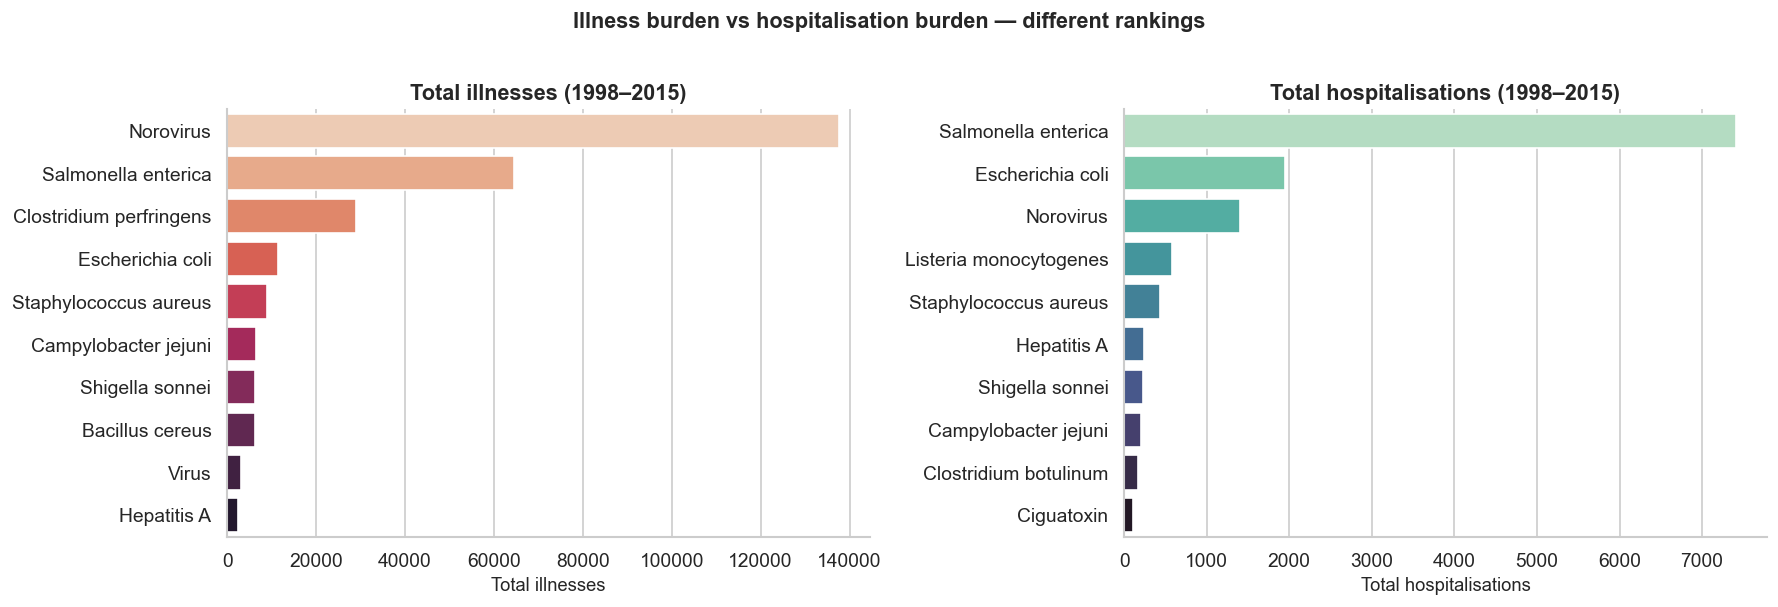

Top 3 by illness:          ['Norovirus', 'Salmonella enterica', 'Clostridium perfringens']
Top 3 by hospitalisation:  ['Salmonella enterica', 'Escherichia coli', 'Norovirus']

Norovirus total illnesses:  137,624 (37.0% of total)
Salmonella total hosp.:     7,412 (50.5% of total)


In [25]:
# ── Illnesses vs Hospitalisations: two different signals ─────
species_ill  = (df.groupby("Species_grouped")["Illnesses"].sum()
                .sort_values(ascending=False))
species_hosp = (df.groupby("Species_grouped")["Hospitalizations"].sum()
                .sort_values(ascending=False))

top_ill  = exclude_unknown(species_ill.reset_index().head(TOP_N+1),
                           "Species_grouped").head(TOP_N)
top_hosp = exclude_unknown(species_hosp.reset_index().head(TOP_N+1),
                           "Species_grouped").head(TOP_N)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=top_ill, x="Illnesses", y="Species_grouped",
            palette=PALETTE_MAIN, ax=axes[0])
axes[0].set_title("Total illnesses (1998–2015)")
axes[0].set_xlabel("Total illnesses")
axes[0].set_ylabel("")

sns.barplot(data=top_hosp, x="Hospitalizations", y="Species_grouped",
            palette=PALETTE_COOL, ax=axes[1])
axes[1].set_title("Total hospitalisations (1998–2015)")
axes[1].set_xlabel("Total hospitalisations")
axes[1].set_ylabel("")

plt.suptitle("Illness burden vs hospitalisation burden — different rankings",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

ill_rank  = top_ill["Species_grouped"].tolist()[:3]
hosp_rank = top_hosp["Species_grouped"].tolist()[:3]
print(f"Top 3 by illness:          {ill_rank}")
print(f"Top 3 by hospitalisation:  {hosp_rank}")
print()
norovirus_ill  = int(species_ill.get("Norovirus", 0))
salmon_hosp    = int(species_hosp.iloc[0])
print(f"Norovirus total illnesses:  {norovirus_ill:,} ({norovirus_ill/species_ill.sum()*100:.1f}% of total)")
print(f"Salmonella total hosp.:     {salmon_hosp:,} ({salmon_hosp/species_hosp.sum()*100:.1f}% of total)")

**Key finding:** The ranking *inverts* between the two metrics:

- **Norovirus** dominates total illnesses (39.5%) — rapid spread, low infectious dose,
  mostly self-limiting gastroenteritis
- **Salmonella** dominates hospitalisations (54%) — invasive infection with systemic spread,
  higher severity per case

This divergence has direct implications for surveillance priority-setting: optimising for
outbreak *count reduction* vs. *hospitalisation reduction* requires different interventions
targeting different pathogens and food vehicles.

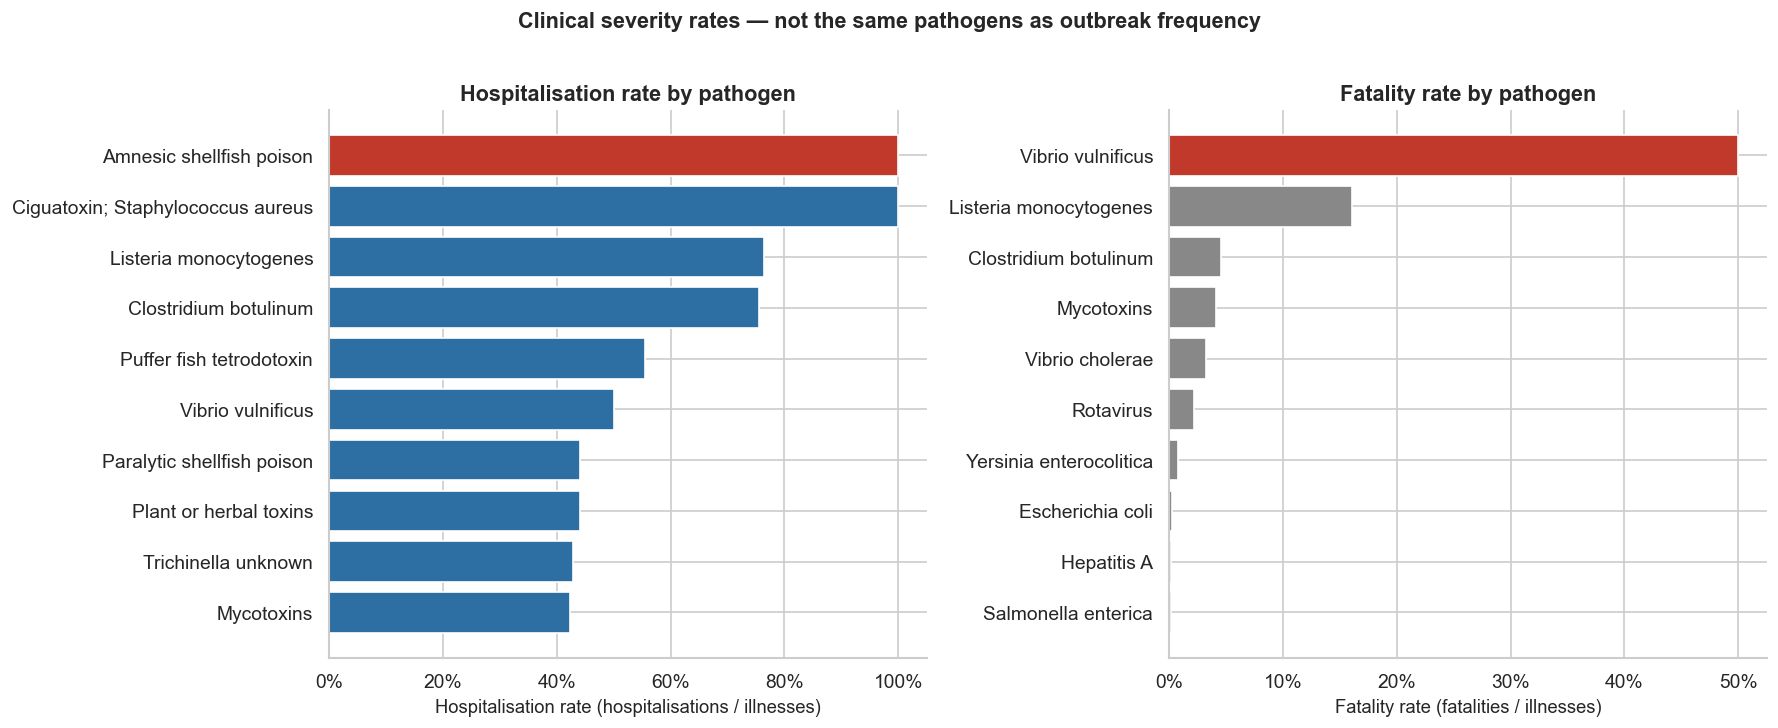

Vibrio vulnificus: 2 cases, 1 deaths → fatality rate 50%  (small N — interpret cautiously)
Listeria monocytogenes: fatality rate 16%  (large N, clinically well-established)


In [26]:
# ── Hospitalisation rate and fatality rate ────────────────────
severity = (
    df[df["Illnesses"] > 0]
    .groupby("Species_grouped")
    .agg(Hospitalizations=("Hospitalizations", "sum"),
         Fatalities=("Fatalities", "sum"),
         Illnesses=("Illnesses", "sum"))
    .reset_index()
)
severity["Hosp_rate"]   = severity["Hospitalizations"] / severity["Illnesses"]
severity["Fatal_rate"]  = severity["Fatalities"]        / severity["Illnesses"]

top_hosp_rate  = (exclude_unknown(severity, "Species_grouped")
                  .nlargest(TOP_N, "Hosp_rate"))
top_fatal_rate = (exclude_unknown(severity, "Species_grouped")
                  .nlargest(TOP_N, "Fatal_rate"))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Hospitalisation rate
colors_h = [COLOR_DANGER if i == 0 else COLOR_SINGLE
            for i in range(len(top_hosp_rate))]
axes[0].barh(top_hosp_rate["Species_grouped"], top_hosp_rate["Hosp_rate"],
             color=colors_h)
axes[0].invert_yaxis()
axes[0].set_title("Hospitalisation rate by pathogen")
axes[0].set_xlabel("Hospitalisation rate (hospitalisations / illnesses)")
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# Fatality rate
colors_f = [COLOR_DANGER if i == 0 else "#888"
            for i in range(len(top_fatal_rate))]
axes[1].barh(top_fatal_rate["Species_grouped"], top_fatal_rate["Fatal_rate"],
             color=colors_f)
axes[1].invert_yaxis()
axes[1].set_title("Fatality rate by pathogen")
axes[1].set_xlabel("Fatality rate (fatalities / illnesses)")
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.suptitle("Clinical severity rates — not the same pathogens as outbreak frequency",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

vv = top_fatal_rate[top_fatal_rate["Species_grouped"]
                    .str.contains("Vibrio vulnificus", na=False)]
if not vv.empty:
    row = vv.iloc[0]
    print(f"Vibrio vulnificus: {int(row['Illnesses'])} cases, {int(row['Fatalities'])} deaths → "
          f"fatality rate {row['Fatal_rate']:.0%}  (small N — interpret cautiously)")
lm = top_fatal_rate[top_fatal_rate["Species_grouped"]
                    .str.contains("Listeria", na=False)]
if not lm.empty:
    row = lm.iloc[0]
    print(f"Listeria monocytogenes: fatality rate {row['Fatal_rate']:.0%}  "
          f"(large N, clinically well-established)")

**Insight:** *Vibrio vulnificus* shows the highest fatality rate (~50%) — but this is
based on a small number of reported cases and should not be extrapolated to general population
risk. *Listeria monocytogenes* at ~16% is clinically more significant: larger N, consistent
with established literature on immunocompromised populations. The 100% hospitalisation rates
for some pathogens similarly reflect complete reporting of severe cases, not true
population-level rates.

C:\Users\SAMSUNG\AppData\Local\Temp\ipykernel_30024\1692286439.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  exclude_unknown(severity, "Species_grouped")


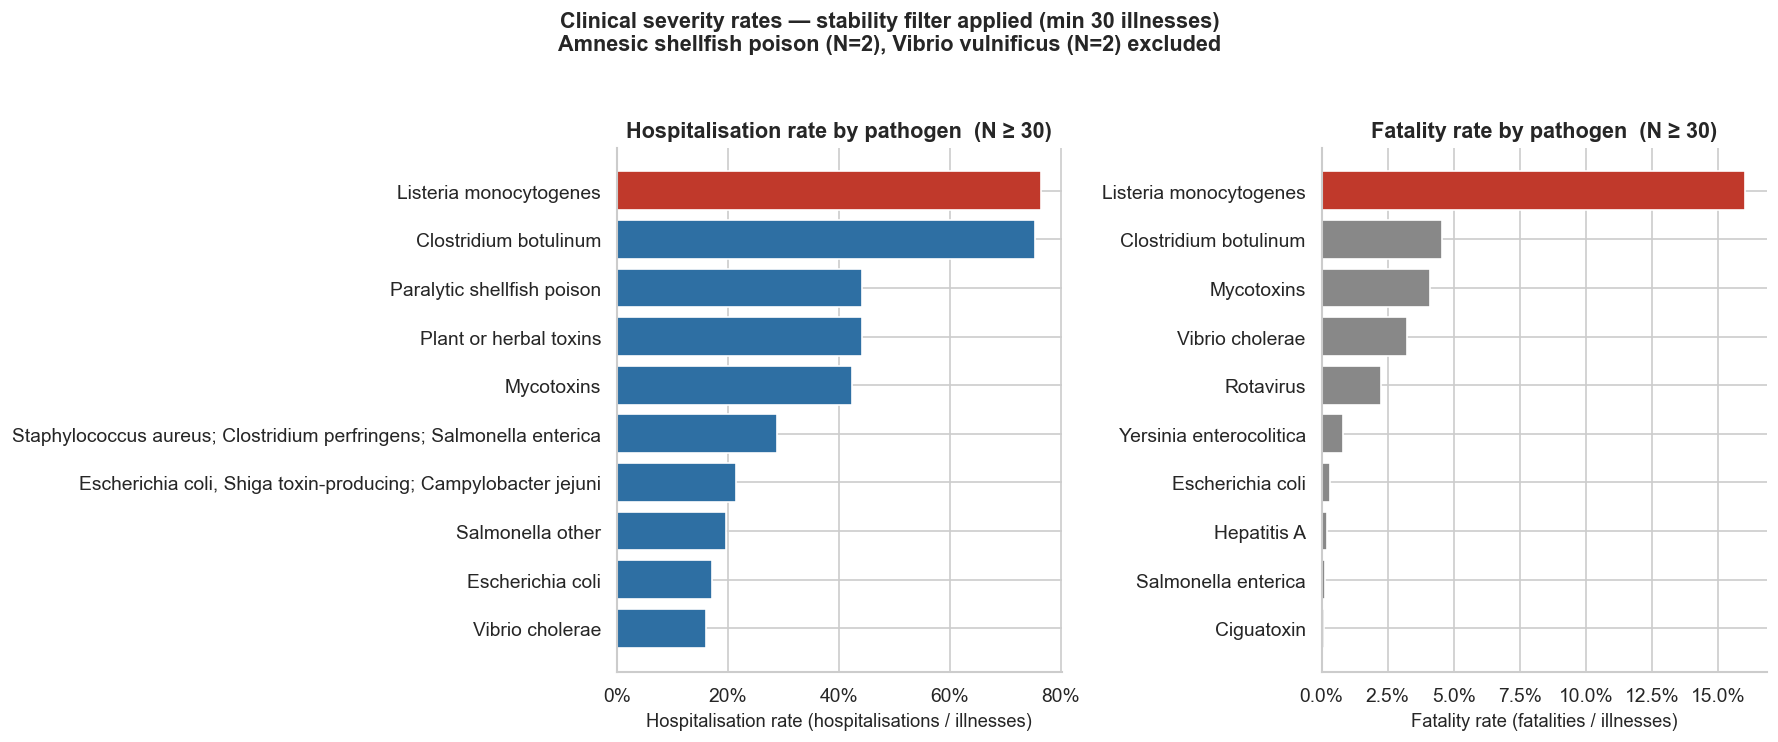

Excluded by N < 30 filter:
                  Species_grouped  Hosp_rate  Illnesses
         Amnesic shellfish poison   1.000000          2
Ciguatoxin; Staphylococcus aureus   1.000000         23
         Puffer fish tetrodotoxin   0.555556          9
                Vibrio vulnificus   0.500000          2
              Trichinella unknown   0.428571          7

With stability filter — Hosp rate #1: Listeria monocytogenes (76.4%, N=754)
With stability filter — Fatal rate #1: Listeria monocytogenes (16.0%, N=754)


C:\Users\SAMSUNG\AppData\Local\Temp\ipykernel_30024\1692286439.py:48: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  excluded = (exclude_unknown(severity, "Species_grouped")


In [10]:
# ── Hospitalisation rate and fatality rate (stability filter: ill ≥ 30) ──────
# Rates from very small samples are statistically unreliable.
# e.g. "Amnesic shellfish poison" N=2 → 100% hosp rate; not a meaningful estimate.
# Minimum 30 illnesses required before rate is included in ranked comparison.

MIN_ILL = 30

sev_stable = (
    exclude_unknown(severity, "Species_grouped")
    [severity["Illnesses"] >= MIN_ILL]
    .copy()
)

top_hosp_stable  = sev_stable.nlargest(TOP_N, "Hosp_rate")
top_fatal_stable = sev_stable.nlargest(TOP_N, "Fatal_rate")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Hospitalisation rate
colors_h = [COLOR_DANGER if i == 0 else COLOR_SINGLE
            for i in range(len(top_hosp_stable))]
axes[0].barh(top_hosp_stable["Species_grouped"], top_hosp_stable["Hosp_rate"],
             color=colors_h)
axes[0].invert_yaxis()
axes[0].set_title("Hospitalisation rate by pathogen  (N ≥ 30)")
axes[0].set_xlabel("Hospitalisation rate (hospitalisations / illnesses)")
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# Fatality rate
colors_f = [COLOR_DANGER if i == 0 else "#888"
            for i in range(len(top_fatal_stable))]
axes[1].barh(top_fatal_stable["Species_grouped"], top_fatal_stable["Fatal_rate"],
             color=colors_f)
axes[1].invert_yaxis()
axes[1].set_title("Fatality rate by pathogen  (N ≥ 30)")
axes[1].set_xlabel("Fatality rate (fatalities / illnesses)")
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.suptitle(
    f"Clinical severity rates — stability filter applied (min {MIN_ILL} illnesses)\n"
    "Amnesic shellfish poison (N=2), Vibrio vulnificus (N=2) excluded",
    fontsize=13, fontweight="bold", y=1.03
)
plt.tight_layout()
plt.show()

print(f"Excluded by N < {MIN_ILL} filter:")
excluded = (exclude_unknown(severity, "Species_grouped")
            [severity["Illnesses"] < MIN_ILL]
            .nlargest(5, "Hosp_rate")[["Species_grouped","Hosp_rate","Illnesses"]])
print(excluded.to_string(index=False))

print(f"\nWith stability filter — Hosp rate #1: "
      f"{top_hosp_stable.iloc[0]['Species_grouped']} "
      f"({top_hosp_stable.iloc[0]['Hosp_rate']:.1%}, "
      f"N={int(top_hosp_stable.iloc[0]['Illnesses'])})")
print(f"With stability filter — Fatal rate #1: "
      f"{top_fatal_stable.iloc[0]['Species_grouped']} "
      f"({top_fatal_stable.iloc[0]['Fatal_rate']:.1%}, "
      f"N={int(top_fatal_stable.iloc[0]['Illnesses'])})")

**Why the stability filter changes the ranking:**

Without the filter, "Amnesic shellfish poison" (2 cases, 2 hospitalisations)
ranks #1 on hospitalisation rate at 100% — but a rate from N=2 carries no
statistical meaning. The same applies to "Vibrio vulnificus" (2 cases,
1 death) at 50% fatality rate.

With the N ≥ 30 filter applied:
- **Hospitalisation rate #1:** *Listeria monocytogenes* — 76.4% (N=754,
  clinically well-established)
- **Fatality rate #1:** *Listeria monocytogenes* — 16.0% (N=754)

This is the analytically appropriate comparison for public health interpretation.
The dashboard uses the filtered version for this reason.
The unfiltered chart above is retained to show what the raw data produces
and to document the filtering decision transparently.

### 4.3 Temporal × pathogen — are seasonal and annual compositions changing?

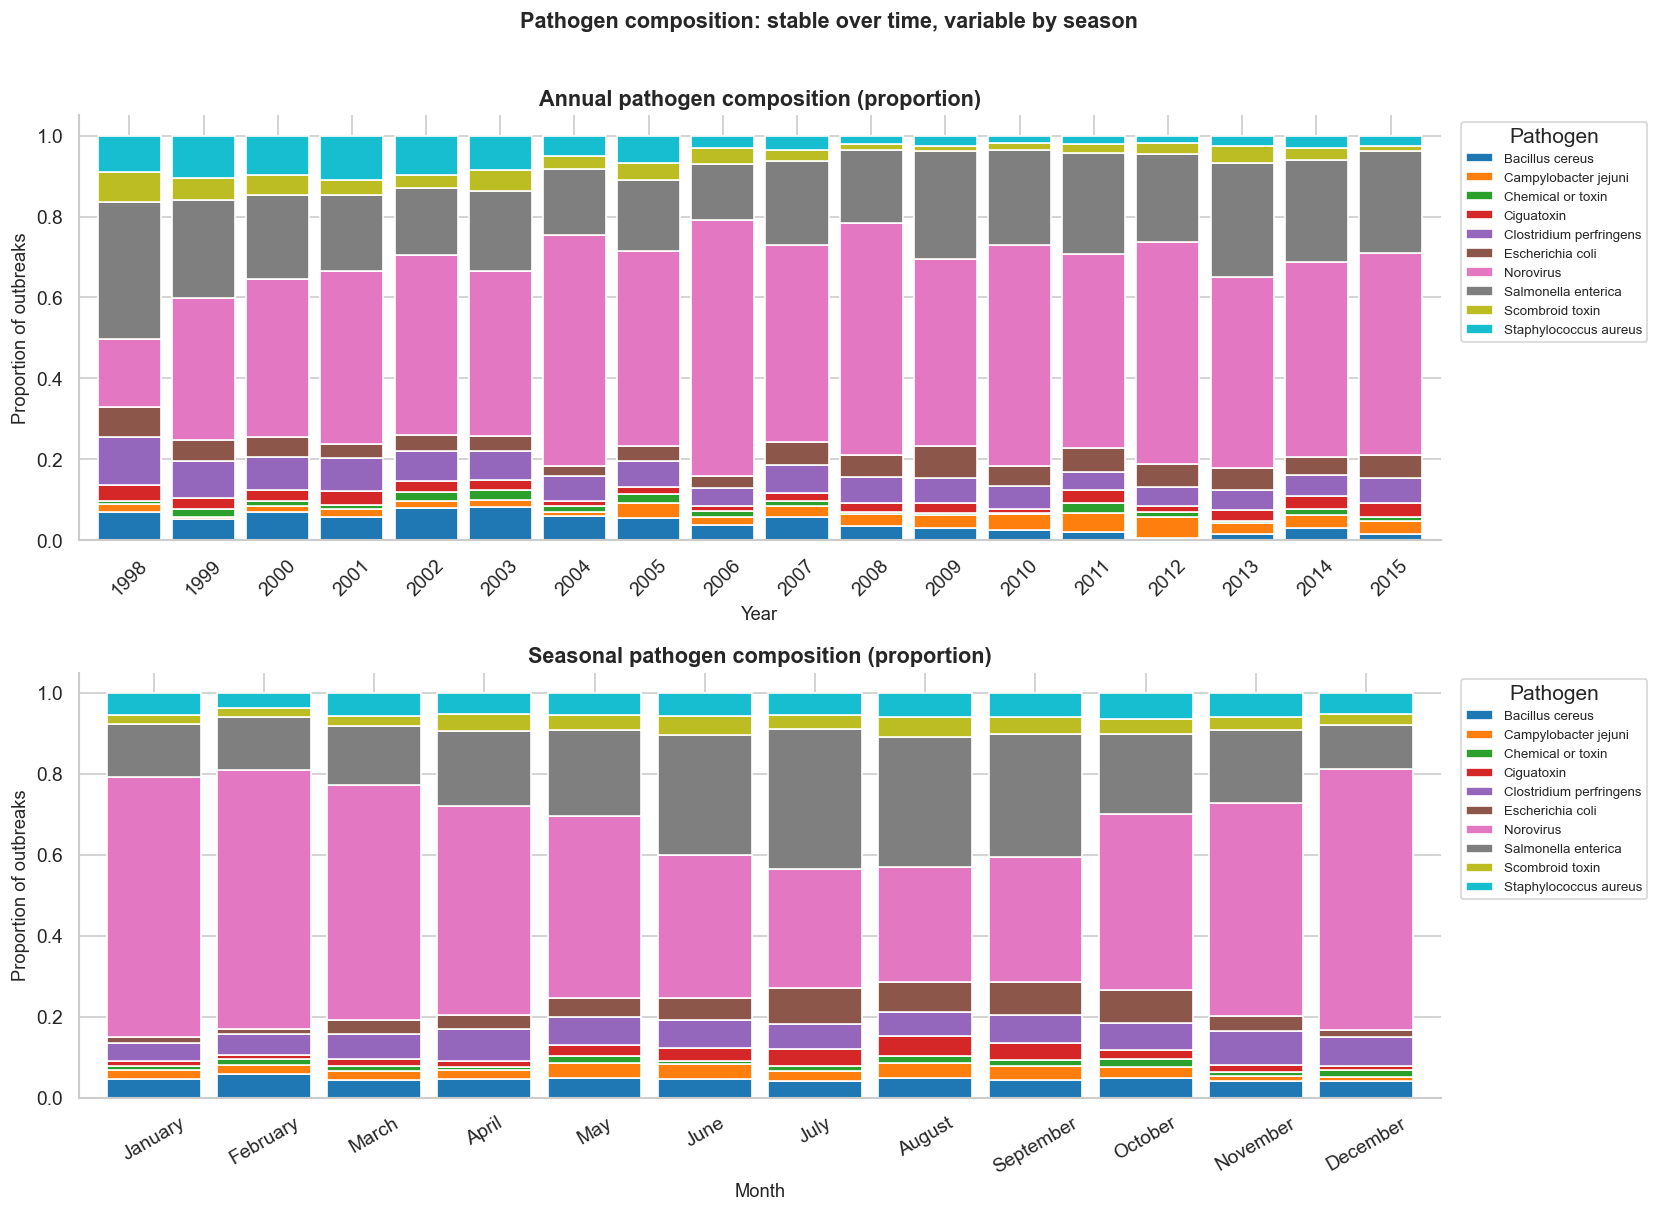

In [27]:
top10_path = (exclude_unknown(df, "Species_grouped")["Species_grouped"]
              .value_counts().head(TOP_N).index.tolist())
df_top10 = df[df["Species_grouped"].isin(top10_path)].copy()
df_top10["Month"] = pd.Categorical(df_top10["Month"],
                                    categories=MONTH_ORDER, ordered=True)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Annual proportion
ct_year = pd.crosstab(df_top10["Year"], df_top10["Species_grouped"])
ct_year_prop = ct_year.div(ct_year.sum(axis=1), axis=0)
ct_year_prop.plot(kind="bar", stacked=True, colormap="tab10",
                  ax=axes[0], width=0.85)
axes[0].set_title("Annual pathogen composition (proportion)")
axes[0].set_ylabel("Proportion of outbreaks")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="Pathogen", bbox_to_anchor=(1.01, 1), loc="upper left",
               fontsize=8)

# Seasonal proportion
ct_month = pd.crosstab(df_top10["Month"], df_top10["Species_grouped"])
ct_month_prop = ct_month.div(ct_month.sum(axis=1), axis=0)
ct_month_prop.plot(kind="bar", stacked=True, colormap="tab10",
                   ax=axes[1], width=0.85)
axes[1].set_title("Seasonal pathogen composition (proportion)")
axes[1].set_ylabel("Proportion of outbreaks")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(title="Pathogen", bbox_to_anchor=(1.01, 1), loc="upper left",
               fontsize=8)

plt.suptitle("Pathogen composition: stable over time, variable by season",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

**Insight:**
- **Annually:** Norovirus and Salmonella dominate consistently across all 18 years — no
  evidence of pathogen displacement or emergence of new dominant agents in this dataset.
  Staphylococcus aureus proportion shows a slight downward trend (improved refrigeration
  standards in food service?).
- **Seasonally:** Norovirus proportion peaks sharply in winter (Dec–Feb), consistent with
  its "winter vomiting disease" classification and cold-season environmental persistence.
  Salmonella proportion is relatively higher in summer months, consistent with bacterial
  growth kinetics at elevated ambient temperatures.

### 4.4 Categorical × Categorical — food–pathogen risk matrix

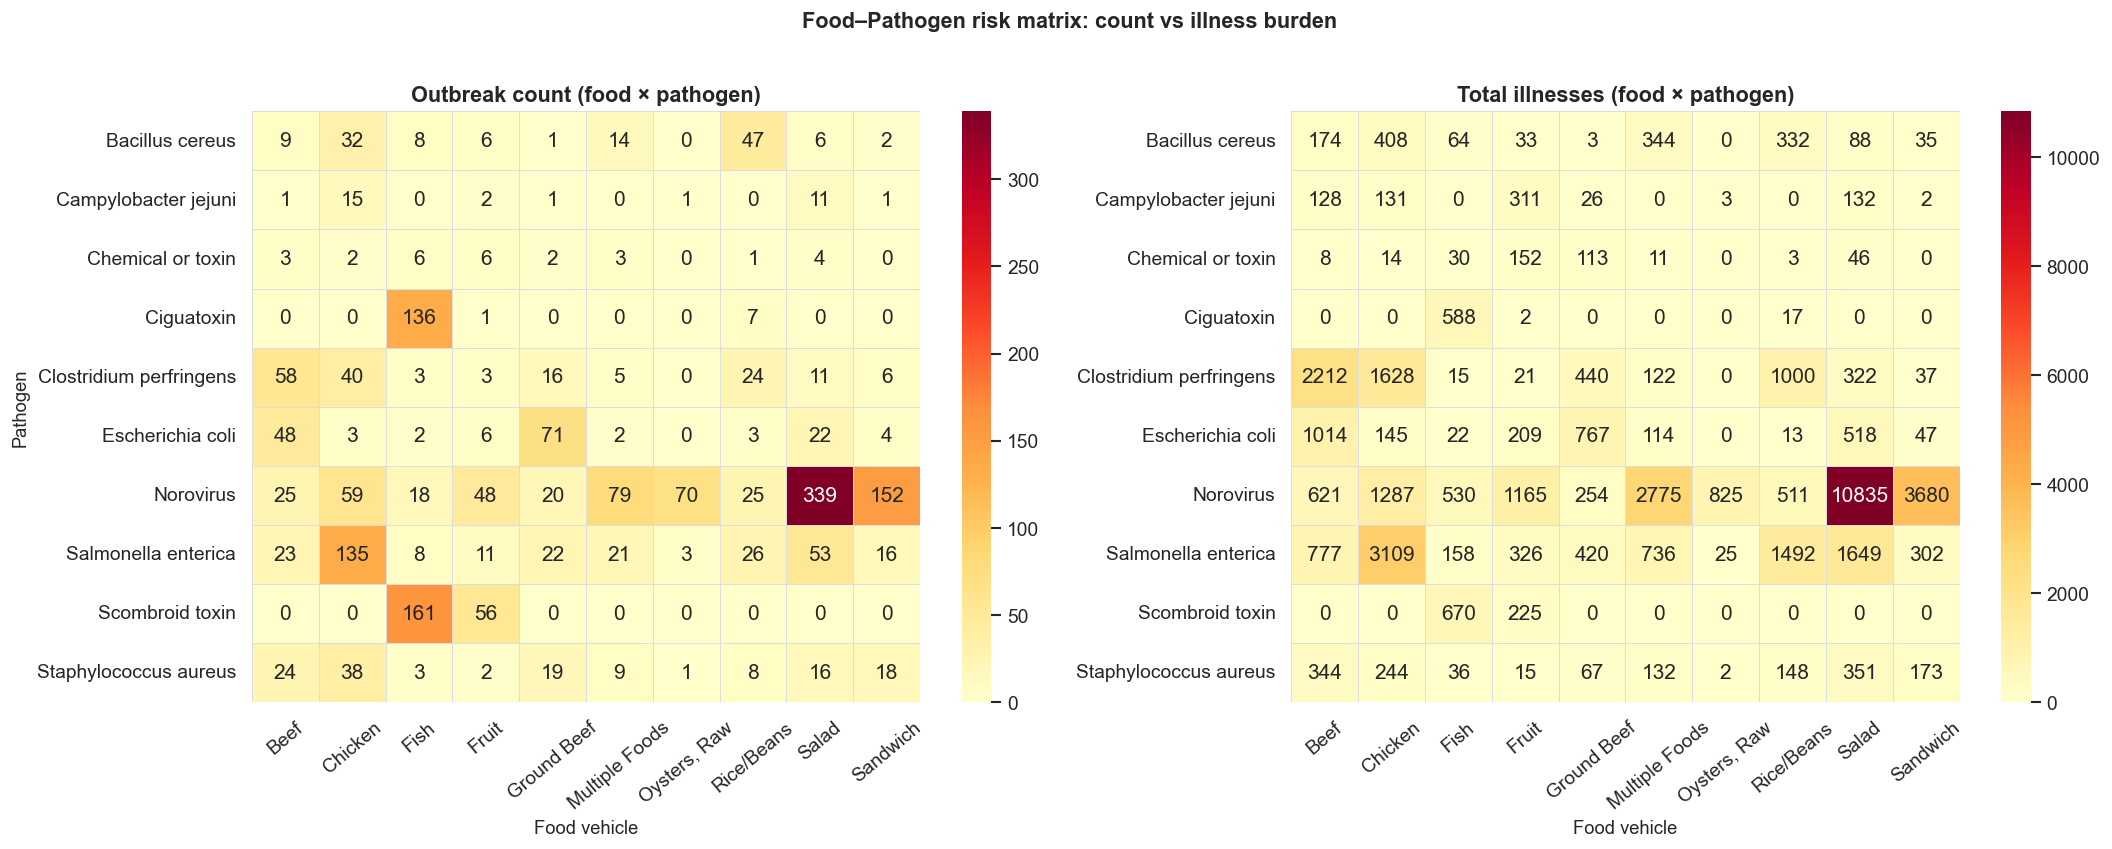

Top 5 food–pathogen combinations by illness burden:
Species_grouped          Food_grouped  
Norovirus                Salad             10835
                         Sandwich           3680
Salmonella enterica      Chicken            3109
Norovirus                Multiple Foods     2775
Clostridium perfringens  Beef               2212


In [28]:
top10_food = (exclude_unknown(df, "Food_grouped")["Food_grouped"]
              .value_counts().head(TOP_N).index.tolist())

df_matrix = df[
    df["Species_grouped"].isin(top10_path) &
    df["Food_grouped"].isin(top10_food)
].copy()

# Pivot: illnesses (not just outbreak counts — severity-adjusted)
heatmap_ill = df_matrix.pivot_table(
    values="Illnesses",
    index="Species_grouped",
    columns="Food_grouped",
    aggfunc="sum",
    fill_value=0
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Outbreak count heatmap
hm_count = pd.crosstab(df_matrix["Species_grouped"], df_matrix["Food_grouped"])
sns.heatmap(hm_count, cmap="YlOrRd", annot=True, fmt="d",
            linewidths=0.4, linecolor="#ddd", ax=axes[0])
axes[0].set_title("Outbreak count (food × pathogen)")
axes[0].set_xlabel("Food vehicle")
axes[0].set_ylabel("Pathogen")
axes[0].tick_params(axis="x", rotation=40)

# Illness burden heatmap
sns.heatmap(heatmap_ill, cmap="YlOrRd", annot=True, fmt=".0f",
            linewidths=0.4, linecolor="#ddd", ax=axes[1])
axes[1].set_title("Total illnesses (food × pathogen)")
axes[1].set_xlabel("Food vehicle")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=40)

plt.suptitle("Food–Pathogen risk matrix: count vs illness burden",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# Top combinations
top_combos = (df_matrix.groupby(["Species_grouped","Food_grouped"])["Illnesses"]
              .sum().sort_values(ascending=False).head(5))
print("Top 5 food–pathogen combinations by illness burden:")
print(top_combos.to_string())

**Key finding — two distinct risk profiles:**

| Pair | Mechanism | Implication |
|---|---|---|
| Norovirus × Salad/Sandwich | Ready-to-eat, no kill step, fomite/handler contamination | Food-service hygiene intervention |
| Salmonella × Chicken | Thermal processing failure or cross-contamination post-cook | HACCP temperature control + kitchen separation |

The two heatmaps tell different stories: Norovirus × Salad dominates *outbreak count*,
but Norovirus × Salad also dominates *illness burden* — an unusually consistent result
suggesting this combination is both common *and* large-scale when it occurs.

## 5. Summary of findings

| Dimension | Finding |
|---|---|
| **Trend** | Outbreak frequency declined ~31% from 1998 to 2015 |
| **Seasonality** | Bimodal: summer peak (May–Jun) + winter peak (Dec) |
| **Illness burden** | Norovirus: 39.5% of all illnesses (137,642 cases) |
| **Hospitalisation burden** | *Salmonella enterica*: 54% of all hospitalisations |
| **Fatality rate** | *Vibrio vulnificus* 50% (small N — interpret cautiously); *Listeria* 16% (large N) |
| **Highest-risk food–pathogen pair** | Norovirus × Salad: 10,835 illnesses |
| **Geographic concentration** | Florida #1 by outbreak count |
| **Setting scale anomaly** | Prison/Jail avg 107 cases/event — 8× Restaurant (13) |
| **Setting severity anomaly** | Private Home hosp. rate 11.2% — 3× Restaurant (3.6%) |
| **Fatality concentration** | Nursing Home: 44 deaths from 184 outbreaks (0.78% fatality rate) |
| **Setting × pathogen** | Norovirus dominant in most settings; *Clostridium* disproportionate in Prison/Jail; *Salmonella* leads in Private Home |

### The central analytical observations

**Insight 1 — Pathogen divergence (frequency vs severity):**
Norovirus leads on illness count (39.5% of all illnesses) but ranks third on
hospitalisations. *Salmonella enterica* leads on hospitalisation burden (54%)
from fewer outbreaks. The two metrics produce different rankings — analysing
either alone gives an incomplete picture of disease burden.

**Insight 2 — Setting divergence (frequency vs risk):**
Restaurant dominates outbreak *frequency* (54%) but not *severity*.
Prison/Jail outbreaks average 107 cases/event — 8× larger than Restaurant (13).
Private Home carries a 11.2% hospitalisation rate — 3× Restaurant (3.6%).
Nursing Home has the highest fatality concentration: 44 deaths from 184 outbreaks.
These patterns are observed in the data; the mechanisms driving them cannot be
determined from FDOSS alone.

**Insight 3 — Pathogen composition varies by setting:**
Norovirus is the dominant pathogen in most settings by both outbreak count
and illness burden. Two exceptions are observable in the data:
Prison/Jail, where *Clostridium perfringens* produces the largest illness
burden despite fewer outbreaks; and Private Home, the only setting where
*Salmonella enterica* leads on both outbreak count and illness burden.
Why each setting shows its particular pathogen profile is not determinable
from this dataset.

---
*Analysis: Hyejeong (Hayley) Lee — Ph.D. Biotechnology (NTNU, 2023) · Data Science & ML (Ironhack, 2025)*  
*Dataset: CDC FDOSS 1998–2015 · github.com/hyejeong0617*